In [1]:
%matplotlib inline
import numpy as np
from skimage import data, util, filters, color
from skimage.morphology import watershed
import matplotlib.pyplot as plt

In [2]:
coins = data.coins()
edges = filters.sobel(coins)

grid = util.regular_grid(coins.shape, n_points= 468)

seeds = np.zeros(coins.shape, dtype=int)
seeds[grid] = np.arange(seeds[grid].size).reshape(seeds[grid].shape) + 1

w0 = watershed(edges, seeds)
w1 = watershed(edges, seeds, compactness= 0.01)

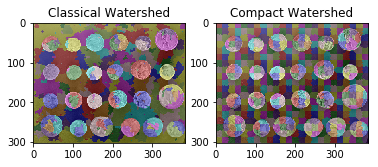

In [4]:
fig, (ax0, ax1) = plt.subplots(1, 2)

ax0.imshow(color.label2rgb(w0, coins))
ax0.set_title('Classical Watershed')

ax1.imshow(color.label2rgb(w1, coins))
ax1.set_title('Compact Watershed')

plt.show()